In [1]:
from qiskit import QuantumCircuit
import json
import phoenix
import numpy as np
from qiskit.circuit import Parameter

In [2]:
phoenix.basics.RXYGate(Parameter('theta'))

Instruction(name='rxy', num_qubits=2, num_clbits=0, params=[Parameter(theta)])

In [3]:
with open('./examples/mol/BeH2_as_2e_3o_JW_sto3g.json') as f:
    data = json.load(f)
data['paulis'] = sorted(data['paulis'], key=lambda p: p.count('I'))
M = 8
data['paulis'][:M]

['YZYYZY',
 'XZXYZY',
 'YZYXZX',
 'XZXXZX',
 'IYYIYY',
 'IXXIYY',
 'IYYIXX',
 'IXXIXX']

In [4]:
paulis = [
    'YZYYZY',
    'XZXYZY',
    'YZYXZI',
    'XZXXZI',
    'IYYIYY',
    'IXXIYY',
    'IYYIIX',
    'IXXIIX'
]
ham = phoenix.Hamiltonian(paulis, data['coeffs'][:M])

In [5]:
m = 8
n = 5
def rand_paulis(m, n):
    paulis = []
    for _ in range(m):
        p = np.random.choice(['I', 'X', 'Y', 'Z'], size=n)
        paulis.append(''.join(p))
    return sorted(paulis, key=lambda p: p.count('I'))

# paulis = rand_paulis(m, n)
paulis = ['XZXXX', 'XYXXZ', 'YXXIX', 'XZYZI', 'YZXIY', 'YZIIZ', 'IYXIZ', 'IYIZX']
ham = phoenix.Hamiltonian([p[::-1] for p in paulis], np.random.rand(m))

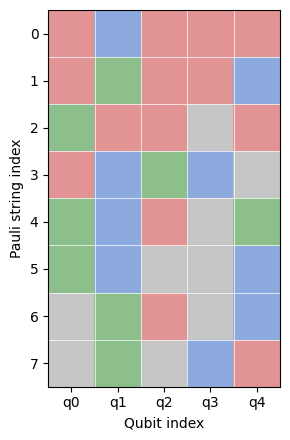

In [6]:
phoenix.utils.plot_pauli_strings(paulis, title=None, figsize=(3,4.5))

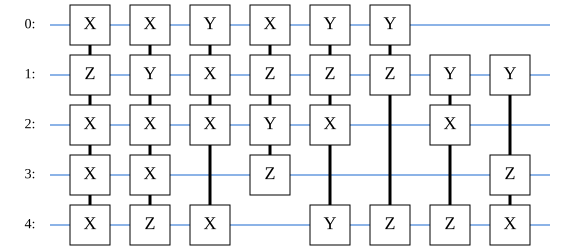

In [7]:
phoenix.utils.plot_pauli_exponential_circuit(paulis)

In [11]:
ham = phoenix.Hamiltonian([p[::-1] for p in paulis], np.random.rand(m))
qc = phoenix.primitive.holistic_compile(ham, verbose=True, terminal='synth', rho_threshold=1.0)

  [T2] target: row 6, w=3
  move 1 [T2]: czz@(1,4)
  [emit-policy] rho=0.6750, threshold=1.0000, emit_weight_2=True
  t=1: emit ['IIXYI']
  [T2] target: row 4, w=3
  move 2 [T2]: czx@(0,2)
  [emit-policy] rho=0.6286, threshold=1.0000, emit_weight_2=True
  t=2: emit ['YIIIY']
  [T2] target: row 2, w=3
  move 3 [T2]: cyx@(0,1)
  [emit-policy] rho=0.6000, threshold=1.0000, emit_weight_2=True
  t=3: emit ['YIIYI']
  [T2] target: row 1, w=3
  move 4 [T2]: czz@(1,3)
  [emit-policy] rho=0.5600, threshold=1.0000, emit_weight_2=True
  t=4: emit ['IXIIZ', 'YIIXI']
  [T2] target: row 3, w=3
  move 5 [T2]: czy@(1,3)
  [emit-policy] rho=0.5333, threshold=1.0000, emit_weight_2=True
  t=5: emit ['IZZII']
  [T2] target: row 0, w=3
  move 6 [T2]: czx@(1,4)
  [emit-policy] rho=0.5000, threshold=1.0000, emit_weight_2=True
  t=6: emit ['IIIYX', 'ZIXII']


In [12]:
qc.draw(fold=-1)


┌──────┐              ┌──────────────┐                                ┌──────┐                        ┌───────────────┐┌───┐                                                                                ┌───┐┌────────────┐┌───┐ ┌───┐  ┌───┐┌───┐     ┌───┐┌───┐┌───┐     ┌───┐
q_0: ┤0     ├──────────────┤0             ├────────────────────────────────┤0     ├────────────────────────┤0              ├┤ H ├────────────────────────────────────────────────────────────────────────────────┤ X ├┤ Rz(1.0593) ├┤ X ├─┤ H ├──┤ S ├┤ H ├──■──┤ H ├┤ X ├┤ S ├──■──┤ X ├
     │      │┌──────┐┌────┐│              │┌───┐┌────────────┐┌───┐┌──────┐│  Cyx │┌──────────────┐┌──────┐│               │├───┤┌───┐┌──────────────┐┌───┐ ┌───┐  ┌──────┐             ┌──────┐      ┌────┐     └─┬─┘└────────────┘└─┬─┘┌┴───┴─┐└───┘└───┘┌─┴─┐├───┤└─┬─┘└───┘  │  └───┘
q_1: ┤  Czx ├┤0     ├┤ √X ├┤              ├┤ X ├┤ Rz(1.1773) ├┤ X ├┤ √Xdg ├┤1     ├┤0             ├┤0     ├┤               ├┤ H ├┤ X ├┤ Rz(-0.20124) ├┤ X ├─┤ H ├──┤0     ├─────────────┤0     ├──────┤ √X ├───────■──────────────────■──┤ √Xdg ├──■────■──┤ X ├┤ Y ├──┼─────────┼───────
     │      ││      │├───┬┘│              │└─┬─┘└────────────┘└─┬─┘└┬───┬─┘└──────┘│              ││      ││  Rzx(-1.3708) │└───┘└─┬─┘└──────────────┘└─┬─┘ └───┘  │      │             │      │┌─────┴────┴────┐                        └──────┘  │    │  └───┘└───┘  │       ┌─┴─┐┌───┐
q_2: ┤1     ├┤      ├┤ H ├─┤  Ryy(1.1482) ├──■──────────────────■───┤ H ├──────────┤              ├┤  Czz ├┤               ├───────┼────────────────────┼──────────┤  Czy ├─■───────────┤      ├┤1              ├──────────────────────────────────┼────┼──────────────┼───────┤ X ├┤ X ├
     └──────┘│  Czz │└───┘ │              │                         └───┘          │  Ryy(1.5153) ││      ││               │       │                    │          │      │ │ZZ(1.0313) │  Czx ││               │                                ┌─┴─┐  │              │       └───┘└───┘
q_3: ────────┤      ├──────┤              ├────────────────────────────────────────┤              ├┤1     ├┤1              ├───────┼────────────────────┼──────────┤1     ├─■───────────┤      ├┤  Rzx(0.18318) ├────────────────────────────────┤ X ├──┼──────────────┼─────────────────
             │      │      │              │                                        │              │└┬────┬┘└───────────────┘       │                    │  ┌──────┐└──────┘             │      ││               │┌───┐                           └───┘┌─┴─┐┌───┐       │                 
q_4: ────────┤1     ├──────┤1             ├────────────────────────────────────────┤1             ├─┤ √X ├─────────────────────────■────────────────────■──┤ √Xdg ├─────────────────────┤1     ├┤0              ├┤ S ├────────────────────────────────┤ X ├┤ S ├───────■─────────────────
             └──────┘      └──────────────┘                                        └──────────────┘ └────┘                                                 └──────┘                     └──────┘└───────────────┘└───┘                                └───┘└───┘

In [10]:
qc.draw(fold=-1)


┌──────┐              ┌─────────────┐                                ┌──────┐                         ┌───────────────┐┌───┐                                                                                  ┌───┐┌────────────┐┌───┐ ┌───┐                          ┌──────┐┌──────┐        
q_0: ┤0     ├──────────────┤0            ├────────────────────────────────┤0     ├─────────────────────────┤0              ├┤ H ├──────────────────────────────────────────────────────────────────────────────────┤ X ├┤ Rz(1.4601) ├┤ X ├─┤ H ├──────────────────────────┤0     ├┤0     ├────────
     │      │┌──────┐┌────┐│             │┌───┐┌────────────┐┌───┐┌──────┐│  Cyx │┌───────────────┐┌──────┐│               │├───┤┌───┐┌───────────────┐┌───┐ ┌───┐  ┌──────┐              ┌──────┐      ┌────┐     └─┬─┘└────────────┘└─┬─┘┌┴───┴─┐┌──────┐┌──────┐┌──────┐│  Cyx ││      │┌──────┐
q_1: ┤  Czx ├┤0     ├┤ √X ├┤             ├┤ X ├┤ Rz(1.7587) ├┤ X ├┤ √Xdg ├┤1     ├┤0              ├┤0     ├┤               ├┤ H ├┤ X ├┤ Rz(-0.035085) ├┤ X ├─┤ H ├──┤0     ├──────────────┤0     ├──────┤ √X ├───────■──────────────────■──┤ √Xdg ├┤0     ├┤0     ├┤0     ├┤1     ├┤  Czx ├┤0     ├
     │      ││      │├───┬┘│             │└─┬─┘└────────────┘└─┬─┘└┬───┬─┘└──────┘│               ││      ││  Rzx(-1.4105) │└───┘└─┬─┘└───────────────┘└─┬─┘ └───┘  │      │              │      │┌─────┴────┴────┐                        └──────┘│      ││      ││      │└──────┘│      ││      │
q_2: ┤1     ├┤      ├┤ H ├─┤  Ryy(1.464) ├──■──────────────────■───┤ H ├──────────┤               ├┤  Czz ├┤               ├───────┼─────────────────────┼──────────┤  Czy ├─■────────────┤      ├┤1              ├────────────────────────────────┤      ├┤  Czy ├┤  Czz ├────────┤1     ├┤      ├
     └──────┘│  Czz │└───┘ │             │                         └───┘          │  Ryy(0.75886) ││      ││               │       │                     │          │      │ │ZZ(0.50028) │  Czx ││               │                                │  Czx ││      ││      │        └──────┘│  Czz │
q_3: ────────┤      ├──────┤             ├────────────────────────────────────────┤               ├┤1     ├┤1              ├───────┼─────────────────────┼──────────┤1     ├─■────────────┤      ├┤  Rzx(0.70965) ├────────────────────────────────┤      ├┤1     ├┤1     ├────────────────┤      ├
             │      │      │             │                                        │               │└┬────┬┘└───────────────┘       │                     │  ┌──────┐└──────┘              │      ││               │                                │      │└──────┘└──────┘                │      │
q_4: ────────┤1     ├──────┤1            ├────────────────────────────────────────┤1              ├─┤ √X ├─────────────────────────■─────────────────────■──┤ √Xdg ├──────────────────────┤1     ├┤0              ├────────────────────────────────┤1     ├────────────────────────────────┤1     ├
             └──────┘      └─────────────┘                                        └───────────────┘ └────┘                                                  └──────┘                      └──────┘└───────────────┘                                └──────┘                                └──────┘

In [16]:
qc1 = phoenix.compile_hamiltonian_simulation(ham, rho_threshold=0.0)
qc2 = phoenix.compile_hamiltonian_simulation(ham, rho_threshold=1.0)
phoenix.utils.print_circ_info(qc1)
phoenix.utils.print_circ_info(qc2)

+------------+-----------+--------------+-------+----------+
| num_qubits | num_gates | num_2q_gates | depth | depth_2q |
+------------+-----------+--------------+-------+----------+
|     5      |     68    |      21      |   33  |    16    |
+------------+-----------+--------------+-------+----------+
+------------+-----------+--------------+-------+----------+
| num_qubits | num_gates | num_2q_gates | depth | depth_2q |
+------------+-----------+--------------+-------+----------+
|     5      |     75    |      24      |   34  |    17    |
+------------+-----------+--------------+-------+----------+


In [13]:
qc1 = phoenix.compile_hamiltonian_simulation(ham, rho_threshold=0.0)
qc2 = phoenix.compile_hamiltonian_simulation(ham, rho_threshold=1.0)
phoenix.utils.print_circ_info(qc1)
phoenix.utils.print_circ_info(qc2)

+------------+-----------+--------------+-------+----------+
| num_qubits | num_gates | num_2q_gates | depth | depth_2q |
+------------+-----------+--------------+-------+----------+
|     5      |     68    |      21      |   33  |    16    |
+------------+-----------+--------------+-------+----------+
+------------+-----------+--------------+-------+----------+
| num_qubits | num_gates | num_2q_gates | depth | depth_2q |
+------------+-----------+--------------+-------+----------+
|     5      |     75    |      24      |   34  |    17    |
+------------+-----------+--------------+-------+----------+


In [14]:
qc_qiskit = phoenix.utils.compile_by_qiskit(ham.paulis.to_labels(), ham.coeffs)
qc_tket = phoenix.utils.compile_by_tket(ham.paulis.to_labels(), ham.coeffs)
phoenix.utils.print_circ_info(qc_qiskit)
phoenix.utils.print_circ_info(qc_tket)

+------------+-----------+--------------+-------+----------+
| num_qubits | num_gates | num_2q_gates | depth | depth_2q |
+------------+-----------+--------------+-------+----------+
|     5      |     74    |      23      |   45  |    22    |
+------------+-----------+--------------+-------+----------+
+------------+-----------+--------------+-------+----------+
| num_qubits | num_gates | num_2q_gates | depth | depth_2q |
+------------+-----------+--------------+-------+----------+
|     5      |     83    |      26      |   41  |    20    |
+------------+-----------+--------------+-------+----------+


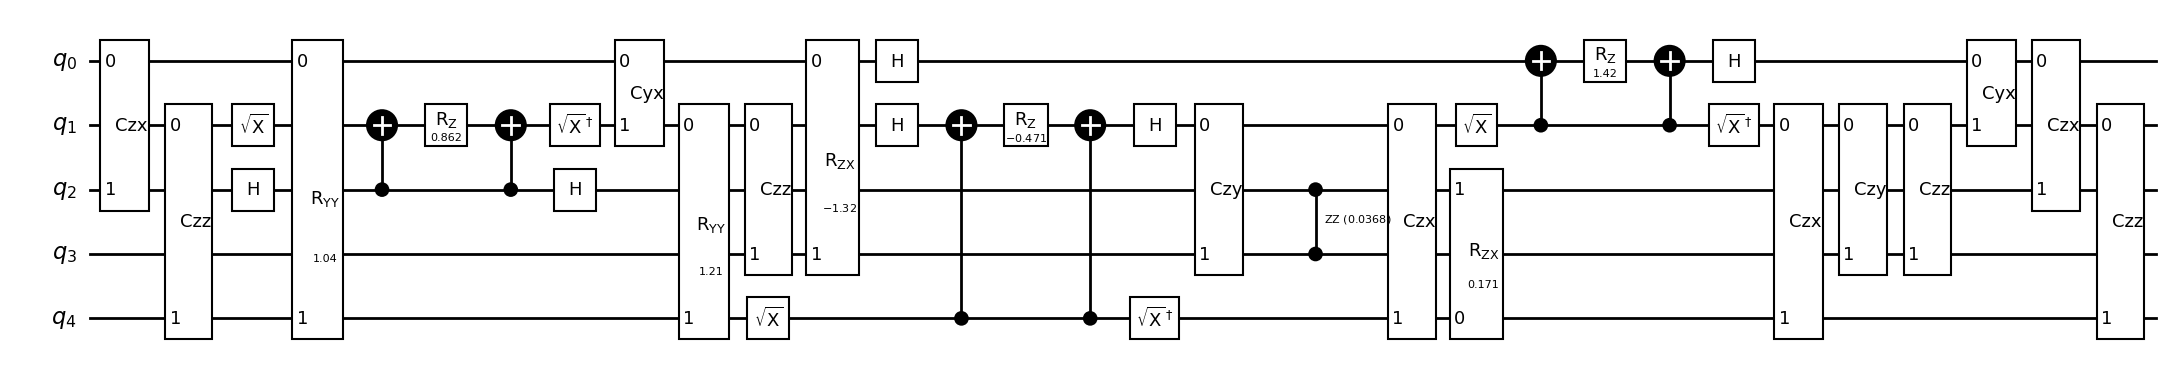

In [25]:
qc.draw('mpl', style='bw', fold=-1)

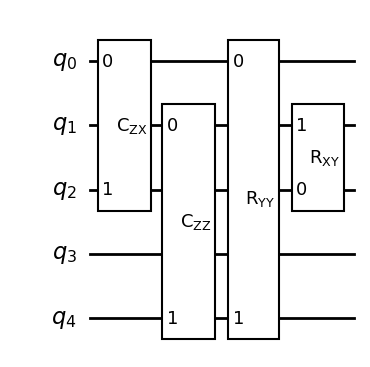

In [61]:
from qiskit.circuit.library import RYYGate, RZZGate, RZXGate, RXXGate
from qiskit.circuit import Parameter
from phoenix.basics import RXYGate

qc_vis = QuantumCircuit(5)
qc_vis.append(phoenix.CNOTEquivCliffordGate('z', 'x'), [0, 2])
qc_vis.append(phoenix.CNOTEquivCliffordGate('z', 'z'), [1, 4])
qc_vis.append(RYYGate(Parameter(' ')), [0, 4])
qc_vis.append(RXYGate(Parameter('')), [2, 1])

qc_vis.draw('mpl', style={
        "name": "bw",
        "displaytext": {
            "cxx": r"C_{XX}",
            "cxy": r"C_{XY}",
            "cxz": r"C_{XZ}",
            "cyx": r"C_{YX}",
            "cyy": r"C_{YY}",
            "cyz": r"C_{YZ}",
            "czx": r"C_{ZX}",
            "czy": r"C_{ZY}",
            "czz": r"C_{ZZ}",
            "rxy": r"R_{XY}",
        },
    }, fold=-1, filename='qc_vis_part1.svg')

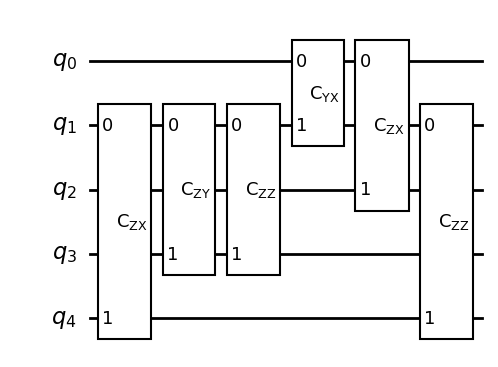

In [62]:
# phoenix.utils.peel_tail_cliffords(qc)[1].draw('mpl', style='bw', fold=-1)
qc_vis = QuantumCircuit(5)
for instr in qc.data[-6:]:
    qc_vis.append(instr)
qc_vis.draw('mpl', style={
        "name": "bw",
        "displaytext": {
            "cxx": r"C_{XX}",
            "cxy": r"C_{XY}",
            "cxz": r"C_{XZ}",
            "cyx": r"C_{YX}",
            "cyy": r"C_{YY}",
            "cyz": r"C_{YZ}",
            "czx": r"C_{ZX}",
            "czy": r"C_{ZY}",
            "czz": r"C_{ZZ}",
        },
    }, fold=-1, filename='qc_vis_part2.svg')

In [18]:
ham.apply_clifford(phoenix.CNOTEquivCliffordGate('z', 'z'), 1, 4).apply_clifford(phoenix.CNOTEquivCliffordGate('z', 'x'), 0, 2).print_tableau()

+-----------------------------------+
|        Qubit index: q0...q4       |
+-------+-----------+-----------+---+
| Pauli |   X part  |   Z part  | s |
+-------+-----------+-----------+---+
| XIIXX | 1 0 0 1 1 | 0 0 0 0 0 | 0 |
| XYIXI | 1 1 0 1 0 | 0 1 0 0 0 | 0 |
| YYIIY | 1 1 0 0 1 | 1 1 0 0 1 | 0 |
| YZZZI | 1 0 0 0 0 | 1 1 1 1 0 | 0 |
| YIIIY | 1 0 0 0 1 | 1 0 0 0 1 | 0 |
| YZXIZ | 1 0 1 0 0 | 1 1 0 0 1 | 0 |
| IYXII | 0 1 1 0 0 | 0 1 0 0 0 | 0 |
| IXIZY | 0 1 0 0 1 | 0 0 0 1 1 | 0 |
+-------+-----------+-----------+---+


In [16]:
ham.print_tableau()

+-----------------------------------+
|        Qubit index: q0...q4       |
+-------+-----------+-----------+---+
| Pauli |   X part  |   Z part  | s |
+-------+-----------+-----------+---+
| XZXXX | 1 0 1 1 1 | 0 1 0 0 0 | 0 |
| XYXXZ | 1 1 1 1 0 | 0 1 0 0 1 | 0 |
| YXXIX | 1 1 1 0 1 | 1 0 0 0 0 | 0 |
| XZYZI | 1 0 1 0 0 | 0 1 1 1 0 | 0 |
| YZXIY | 1 0 1 0 1 | 1 1 0 0 1 | 0 |
| YZIIZ | 1 0 0 0 0 | 1 1 0 0 1 | 0 |
| IYXIZ | 0 1 1 0 0 | 0 1 0 0 1 | 0 |
| IYIZX | 0 1 0 0 1 | 0 1 0 1 0 | 0 |
+-------+-----------+-----------+---+


In [31]:
from pathlib import Path


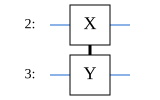

In [33]:
svg_circuit = phoenix.utils.plot_pauli_exponentials(['IIXYI'])
Path("emission1.svg").write_text(svg_circuit._repr_svg_(), encoding="utf-8")
svg_circuit

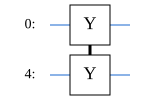

In [34]:
svg_circuit = phoenix.utils.plot_pauli_exponentials(['YIIIY'])
Path("emission2.svg").write_text(svg_circuit._repr_svg_(), encoding="utf-8")
svg_circuit

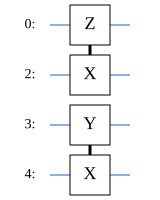

In [35]:
svg_circuit = phoenix.utils.plot_pauli_exponentials(['IIIYX', 'ZIXII'])
Path("emissionL.svg").write_text(svg_circuit._repr_svg_(), encoding="utf-8")
svg_circuit

In [36]:
import cirq
c = cirq.Circuit()
c.append(cirq.ISWAP(cirq.LineQubit(0), cirq.LineQubit(1)))
cirq.contrib.svg.SVGCircuit(c)

import cairosvg

svg_circuit = cirq.contrib.svg.svg.SVGCircuit(c)

cairosvg.svg2pdf(
    bytestring=svg_circuit._repr_svg_().encode("utf-8"),
    write_to="circuit.pdf",
)



┌──────┐              ┌───────────────┐                                        ┌──────────────┐ ┌────┐                        ┌───┐┌──────────────┐┌───┐┌──────┐        ┌──────┐              ┌───────────────┐                            ┌──────┐                        ┌──────┐        
q_0: ┤0     ├──────────────┤0              ├────────────────────────────────────────┤0             ├─┤ √X ├────────────────────────┤ X ├┤ Rz(-0.60847) ├┤ X ├┤ √Xdg ├────────┤0     ├──────────────┤0              ├────────────────────────────┤0     ├────────────────────────┤0     ├────────
     │      │              │               │                                        │              │┌┴────┴┐     ┌────────────────┐└─┬─┘└──────────────┘└─┬─┘└──────┘┌──────┐│      │              │               │                            │      │┌──────┐┌──────┐        │      │        
q_1: ┤      ├──────────────┤               ├────────────────────────────────────────┤              ├┤0     ├─────┤1               ├──┼────────────────────┼──────────┤0     ├┤      ├─■────────────┤  Rzx(0.32081) ├────────────────────────────┤      ├┤0     ├┤0     ├────────┤      ├────────
     │  Czz │┌──────┐┌───┐ │               │┌───┐┌────────────┐┌───┐ ┌───┐          │  Ryy(1.9888) ││      │     │                │  │                    │          │      ││  Cxz │ │ZZ(0.29611) │               │                            │  Cxz ││      ││      │        │  Czz │┌──────┐
q_2: ┤      ├┤0     ├┤ H ├─┤  Ryy(0.95562) ├┤ X ├┤ Rz(1.6841) ├┤ X ├─┤ H ├──────────┤              ├┤  Czz ├─────┤                ├──┼────────────────────┼──────────┤  Cyz ├┤      ├─■────────────┤1              ├────────────────────────────┤      ├┤  Cyz ├┤  Czz ├────────┤      ├┤0     ├
     │      ││      │├───┴┐│               │└─┬─┘└────────────┘└─┬─┘┌┴───┴─┐┌──────┐│              ││      │┌───┐│  Rzx(-0.85902) │  │                    │   ┌───┐  │      ││      │    ┌────┐    └─────┬───┬─────┘┌─────────────┐┌───┐┌──────┐│      ││      ││      │┌──────┐│      ││      │
q_3: ┤1     ├┤  Cxz ├┤ √X ├┤               ├──■──────────────────■──┤ √Xdg ├┤0     ├┤1             ├┤1     ├┤ H ├┤                ├──■────────────────────■───┤ H ├──┤1     ├┤1     ├────┤ √X ├──────────┤ X ├──────┤ Rz(0.69248) ├┤ X ├┤ √Xdg ├┤1     ├┤1     ├┤1     ├┤0     ├┤1     ├┤  Cxz ├
     └──────┘│      │└────┘│               │                        └──────┘│  Cxy │└──────────────┘└──────┘└───┘│                │┌───┐                      └───┘  └──────┘└──────┘    └────┘          └─┬─┘      └─────────────┘└─┬─┘└┬───┬─┘└──────┘└──────┘└──────┘│  Cxy │└──────┘│      │
q_4: ────────┤1     ├──────┤1              ├────────────────────────────────┤1     ├─────────────────────────────┤0               ├┤ H ├───────────────────────────────────────────────────────────────────■─────────────────────────■───┤ H ├──────────────────────────┤1     ├────────┤1     ├
             └──────┘      └───────────────┘                                └──────┘                             └────────────────┘└───┘                                                                                                 └───┘                          └──────┘        └──────┘

In [41]:
from graphviz import Digraph

edges = [
    (0, 1), (0, 2), (0, 3),
    (2, 4), (3, 4),
    (1, 5), (2, 5), (4, 5),
    (4, 6),
]

nodes = sorted({n for edge in edges for n in edge})

dot = Digraph("circuit", engine="dot", format="svg")

dot.attr(
    rankdir="LR",        # 从上到下；改为 LR 可从左到右
    bgcolor="white",
    pad="0.15",
    ranksep="0.55",
    nodesep="0.35",
)

dot.attr(
    "node",
    shape="circle",
    label="",            # 不显示节点编号
    style="filled",
    fillcolor="white",
    color="#5BA4E6",     # 天蓝色边框
    penwidth="1.8",
    fixedsize="true",
    width="0.28",
    height="0.28",
)

dot.attr(
    "edge",
    color="#346590",
    penwidth="1.5",
    arrowsize="0.7",
)

for node in nodes:
    dot.node(str(node))  # 节点 ID 仅供内部连边使用，不会显示

for source, target in edges:
    if (source, target) == (2, 4):
        dot.edge(
            str(source), str(target),
            color="#8B1A1A",  # 暗红色
            style="dashed",
            penwidth="1.8",
        )
    else:
        dot.edge(str(source), str(target))

dot.render("directed_graph", cleanup=True, view=False)

'directed_graph.svg'

In [5]:
from itertools import product, combinations

all_2q_paulis = product(['X', 'Y', 'Z'], repeat=2)
all_2q_paulis = [f"{p[0]}{p[1]}" for p in all_2q_paulis]

cnot_cost_stats = {}
for m in range(2, 10):
    paulis_combs = list(combinations(all_2q_paulis, m))
    cnot_cost_stats[m] = []
    for paulis in paulis_combs:
        cnot_cost_stats[m].append(phoenix.utils.pauli_exp_synth_cost(paulis))

In [11]:
cnot_cost_stats_avg = {m: np.mean(cnot_cost_stats[m]) for m in cnot_cost_stats}
cnot_cost_stats_avg

{2: np.float64(2.0),
 3: np.float64(2.0714285714285716),
 4: np.float64(2.2857142857142856),
 5: np.float64(2.642857142857143),
 6: np.float64(2.9285714285714284),
 7: np.float64(3.0),
 8: np.float64(3.0),
 9: np.float64(3.0)}

In [16]:
np.sum([np.sum(cnot_cost_stats[m]) for m in cnot_cost_stats]) / np.sum([len(cnot_cost_stats[m]) for m in cnot_cost_stats])

np.float64(2.49203187250996)

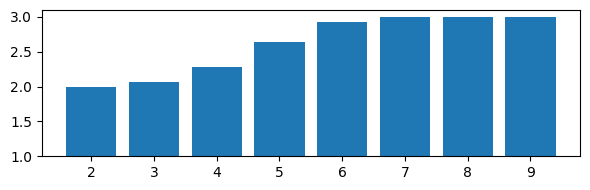

In [28]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(6, 2))
plt.bar(cnot_cost_stats_avg.keys(), cnot_cost_stats_avg.values())
plt.ylim(1, 3.1)
plt.yticks(np.arange(1, 3.1, 0.5))
plt.tight_layout()
plt.savefig("cnot_cost_stats_avg.pdf", bbox_inches='tight')
plt.show()

In [8]:
paulis

['XZXXX', 'XYXXZ', 'YXXIX', 'XZYZI', 'YZXIY', 'YZIIZ', 'IYXIZ', 'IYIZX']

In [53]:
ham.print_tableau()

+-----------------------------------+
|        Qubit index: q0...q4       |
+-------+-----------+-----------+---+
| Pauli |   X part  |   Z part  | s |
+-------+-----------+-----------+---+
| XZXXX | 1 0 1 1 1 | 0 1 0 0 0 | 0 |
| XYXXZ | 1 1 1 1 0 | 0 1 0 0 1 | 0 |
| YXXIX | 1 1 1 0 1 | 1 0 0 0 0 | 0 |
| XZYZI | 1 0 1 0 0 | 0 1 1 1 0 | 0 |
| YZXIY | 1 0 1 0 1 | 1 1 0 0 1 | 0 |
| YZIIZ | 1 0 0 0 0 | 1 1 0 0 1 | 0 |
| IYXIZ | 0 1 1 0 0 | 0 1 0 0 1 | 0 |
| IYIZX | 0 1 0 0 1 | 0 1 0 1 0 | 0 |
+-------+-----------+-----------+---+


In [56]:
qc = phoenix.compile_hamiltonian_simulation(ham, optimize=False, terminal='replay')
qc.draw(fold=-1)

┌──────┐              ┌──────────────┐                                ┌──────┐                         ┌───────────────┐┌───┐                                                                                ┌───┐┌────────────┐┌───┐ ┌───┐                          ┌──────┐┌──────┐        
q_0: ┤0     ├──────────────┤0             ├────────────────────────────────┤0     ├─────────────────────────┤0              ├┤ H ├────────────────────────────────────────────────────────────────────────────────┤ X ├┤ Rz(1.5225) ├┤ X ├─┤ H ├──────────────────────────┤0     ├┤0     ├────────
     │      │┌──────┐┌────┐│              │┌───┐┌────────────┐┌───┐┌──────┐│  Cyx │┌───────────────┐┌──────┐│               │├───┤┌───┐┌──────────────┐┌───┐ ┌───┐  ┌──────┐              ┌──────┐     ┌────┐     └─┬─┘└────────────┘└─┬─┘┌┴───┴─┐┌──────┐┌──────┐┌──────┐│  Cyx ││      │┌──────┐
q_1: ┤  Czx ├┤0     ├┤ √X ├┤              ├┤ X ├┤ Rz(1.6328) ├┤ X ├┤ √Xdg ├┤1     ├┤0              ├┤0     ├┤               ├┤ H ├┤ X ├┤ Rz(-0.46469) ├┤ X ├─┤ H ├──┤0     ├──────────────┤0     ├─────┤ √X ├───────■──────────────────■──┤ √Xdg ├┤0     ├┤0     ├┤0     ├┤1     ├┤  Czx ├┤0     ├
     │      ││      │├───┬┘│              │└─┬─┘└────────────┘└─┬─┘└┬───┬─┘└──────┘│               ││      ││  Rzx(-1.5293) │└───┘└─┬─┘└──────────────┘└─┬─┘ └───┘  │      │              │      │┌────┴────┴────┐                        └──────┘│      ││      ││      │└──────┘│      ││      │
q_2: ┤1     ├┤      ├┤ H ├─┤  Ryy(0.4342) ├──■──────────────────■───┤ H ├──────────┤               ├┤  Czz ├┤               ├───────┼────────────────────┼──────────┤  Czy ├─■────────────┤      ├┤1             ├────────────────────────────────┤      ├┤  Czy ├┤  Czz ├────────┤1     ├┤      ├
     └──────┘│  Czz │└───┘ │              │                         └───┘          │  Ryy(0.10031) ││      ││               │       │                    │          │      │ │ZZ(0.09529) │  Czx ││              │                                │  Czx ││      ││      │        └──────┘│  Czz │
q_3: ────────┤      ├──────┤              ├────────────────────────────────────────┤               ├┤1     ├┤1              ├───────┼────────────────────┼──────────┤1     ├─■────────────┤      ├┤  Rzx(1.9083) ├────────────────────────────────┤      ├┤1     ├┤1     ├────────────────┤      ├
             │      │      │              │                                        │               │└┬────┬┘└───────────────┘       │                    │  ┌──────┐└──────┘              │      ││              │                                │      │└──────┘└──────┘                │      │
q_4: ────────┤1     ├──────┤1             ├────────────────────────────────────────┤1              ├─┤ √X ├─────────────────────────■────────────────────■──┤ √Xdg ├──────────────────────┤1     ├┤0             ├────────────────────────────────┤1     ├────────────────────────────────┤1     ├
             └──────┘      └──────────────┘                                        └───────────────┘ └────┘                                                 └──────┘                      └──────┘└──────────────┘                                └──────┘                                └──────┘

In [43]:
ham.generate_circuit().draw(fold=-1)

┌───┐               ┌───┐┌─────────────┐┌───┐┌───┐                                    ┌───┐┌─────────────┐┌───┐┌───┐                                  ┌───┐┌─────────────┐┌───┐┌───┐┌────┐                                                                                 ┌───┐┌─────────────┐┌───┐┌──────┐                        ┌───┐┌────────────┐┌───┐                  ┌───┐┌─────────────┐┌───┐┌───┐                   ┌───┐┌───────────┐┌───┐┌───┐        
q_0: ┤ H ├───────────────┤ X ├┤ Rz(0.17898) ├┤ X ├┤ H ├────────────────────────────────────┤ X ├┤ Rz(0.87369) ├┤ X ├┤ H ├──────────────────────────────────┤ X ├┤ Rz(0.92454) ├┤ X ├┤ H ├┤ √X ├─────────────────────────────────────────────────────────────────────────────────┤ X ├┤ Rz(0.94678) ├┤ X ├┤ √Xdg ├────────────────────────┤ X ├┤ Rz(1.6855) ├┤ X ├──────────────────┤ X ├┤ Rz(0.58452) ├┤ X ├┤ H ├───────────────────┤ X ├┤ Rz(0.953) ├┤ X ├┤ H ├────────
     ├───┤          ┌───┐└─┬─┘└─────────────┘└─┬─┘├───┤┌───┐┌───┐                     ┌───┐└─┬─┘└─────────────┘└─┬─┘├───┤┌───┐                             └─┬─┘└─────────────┘└─┬─┘└───┘└────┘                       ┌───┐┌────────────┐┌───┐                                  └─┬─┘└─────────────┘└─┬─┘└──────┘                        └─┬─┘└────────────┘└─┬─┘                  └─┬─┘└─────────────┘└─┬─┘└───┘              ┌───┐└─┬─┘└───────────┘└─┬─┘├───┤        
q_1: ┤ H ├──────────┤ X ├──■───────────────────■──┤ X ├┤ H ├┤ H ├─────────────────────┤ X ├──■───────────────────■──┤ X ├┤ H ├───────────────────────────────┼───────────────────┼────────────────────────────────────┤ X ├┤ Rz(1.0645) ├┤ X ├────────────────────────────────────┼───────────────────┼────────────────────────────────────┼──────────────────┼──────────────────────┼───────────────────┼─────────────────────┤ X ├──■─────────────────■──┤ X ├────────
     ├───┤     ┌───┐└─┬─┘                         └─┬─┘├───┤├───┤┌───┐           ┌───┐└─┬─┘                         └─┬─┘├───┤┌───┐ ┌───┐             ┌───┐  │                   │  ┌───┐┌───┐  ┌────┐           ┌───┐└─┬─┘└────────────┘└─┬─┘┌───┐┌──────┐┌───┐           ┌───┐  │                   │   ┌───┐  ┌───┐ ┌───┐               │                  │               ┌───┐  │                   │  ┌───┐ ┌───┐        └─┬─┘                       └─┬─┘        
q_2: ┤ H ├─────┤ X ├──■─────────────────────────────■──┤ X ├┤ H ├┤ H ├───────────┤ X ├──■─────────────────────────────■──┤ X ├┤ H ├─┤ H ├─────────────┤ X ├──■───────────────────■──┤ X ├┤ H ├──┤ √X ├───────────┤ X ├──■──────────────────■──┤ X ├┤ √Xdg ├┤ H ├───────────┤ X ├──■───────────────────■───┤ X ├──┤ H ├─┤ H ├───────────────┼──────────────────┼───────────────┤ X ├──■───────────────────■──┤ X ├─┤ H ├──────────┼───────────────────────────┼──────────
     └───┘┌───┐└─┬─┘                                   └─┬─┘├───┤├───┴┐     ┌───┐└─┬─┘                                   └─┬─┘├───┤┌┴───┴─┐┌───┐ ┌───┐└─┬─┘                         └─┬─┘├───┤  ├───┬┘      ┌───┐└─┬─┘                        └─┬─┘└┬───┬─┘└───┘      ┌───┐└─┬─┘                          └─┬─┘  ├───┤ └───┘        ┌───┐  │                  │  ┌───┐ ┌────┐ └─┬─┘                         └─┬─┘┌┴───┴─┐┌────┐  │                           │  ┌──────┐
q_3: ─────┤ X ├──■───────────────────────────────────────■──┤ X ├┤ √X ├─────┤ X ├──■───────────────────────────────────────■──┤ X ├┤ √Xdg ├┤ H ├─┤ X ├──■─────────────────────────────■──┤ X ├──┤ H ├───────┤ X ├──■────────────────────────────■───┤ X ├─────────────┤ X ├──■──────────────────────────────■────┤ X ├──────────────┤ X ├──■──────────────────■──┤ X ├─┤ √X ├───■─────────────────────────────■──┤ √Xdg ├┤ √X ├──■───────────────────────────■──┤ √Xdg ├
     ┌───┐└─┬─┘                                             └─┬─┘├───┬┘┌───┐└─┬─┘                                             └─┬─┘└┬───┬─┘├───┴┐└─┬─┘                                   └─┬─┘ ┌┴───┴─┐┌───┐└─┬─┘                                   └─┬─┘  ┌───┐┌────┐└─┬─┘                                      └─┬─┘┌──────┐┌────┐└─┬─┘                    

In [44]:
qc_phoenix = phoenix.compile_hamiltonian_simulation(ham, grouping='support')
qc_symphony = phoenix.compile_hamiltonian_simulation(ham)
phoenix.utils.print_circ_info(qc_phoenix, "Phoenix")
phoenix.utils.print_circ_info(qc_symphony, "Symphony")

+----------------------------------------------------------+
|                         Phoenix                          |
+------------+-----------+--------------+-------+----------+
| num_qubits | num_gates | num_2q_gates | depth | depth_2q |
+------------+-----------+--------------+-------+----------+
|     5      |    101    |      32      |   55  |    27    |
+------------+-----------+--------------+-------+----------+
+----------------------------------------------------------+
|                         Symphony                         |
+------------+-----------+--------------+-------+----------+
| num_qubits | num_gates | num_2q_gates | depth | depth_2q |
+------------+-----------+--------------+-------+----------+
|     5      |     86    |      27      |   35  |    17    |
+------------+-----------+--------------+-------+----------+


In [46]:
qc_qiskit = phoenix.utils.compile_by_qiskit(ham.paulis.to_labels(), ham.coeffs)
qc_tket = phoenix.utils.compile_by_tket(ham.paulis.to_labels(), ham.coeffs)
phoenix.utils.print_circ_info(qc_qiskit, "Qiskit")
phoenix.utils.print_circ_info(qc_tket, "tket")

+----------------------------------------------------------+
|                          Qiskit                          |
+------------+-----------+--------------+-------+----------+
| num_qubits | num_gates | num_2q_gates | depth | depth_2q |
+------------+-----------+--------------+-------+----------+
|     5      |     77    |      24      |   41  |    20    |
+------------+-----------+--------------+-------+----------+
+----------------------------------------------------------+
|                           tket                           |
+------------+-----------+--------------+-------+----------+
| num_qubits | num_gates | num_2q_gates | depth | depth_2q |
+------------+-----------+--------------+-------+----------+
|     5      |     95    |      30      |   43  |    21    |
+------------+-----------+--------------+-------+----------+
